#1. Learning MLP classifier

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("winequality-red.csv", delimiter = ';')

X = data.drop(columns=['quality'])
y = data['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

num_runs = 10
residues = []
rmse_sum = 0

for seed in range(1, num_runs + 1):
    mlp = MLPRegressor(hidden_layer_sizes=(10, 10), activation='relu', 
                       random_state=seed, early_stopping=True, validation_fraction=0.2)
    mlp.fit(X_train, y_train)
    y_pred = mlp.predict(X_test)
    residues.extend(np.abs(y_test - y_pred))

    rmse_sum += np.sqrt(mean_squared_error(y_test, y_pred))

rmse_mean = rmse_sum/10

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptro

#Plotting absolute distribution of residues

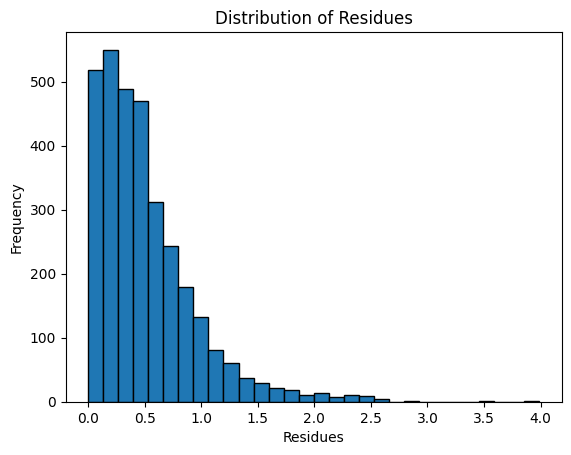

In [ ]:
n, bins, patches = plt.hist(residues, bins=30, edgecolor='k')
plt.xlabel('Residues')
plt.ylabel('Frequency')
plt.title('Distribution of Residues')
plt.show()

#2 Checking the impact on MAE, of rounding and bounding the results of model's output

In [ ]:
rmse_sum = 0
mae_original_sum = 0
mae_rounded_sum = 0
mae_bounded_sum = 0

for seed in range(1, num_runs + 1):
    mlp = MLPRegressor(hidden_layer_sizes=(10, 10), activation='relu', random_state=seed, 
                       early_stopping=True, validation_fraction=0.2)
    mlp.fit(X_train, y_train)
    y_pred = mlp.predict(X_test)
    y_pred_rounded = np.round(y_pred)
    y_pred_bounded = np.clip(y_pred, 3, 8)

    mae_original_sum += mean_absolute_error(y_test, y_pred)
    mae_rounded_sum += mean_absolute_error(y_test, y_pred_rounded)
    mae_bounded_sum += mean_absolute_error(y_test, y_pred_bounded)

mae_original = mae_original_sum/10

mae_rounded = mae_rounded_sum/10
mae_bounded = mae_bounded_sum/10

print(f"MAE without rounding or bounding: {mae_original}")
print(f"MAE with rounding: {mae_rounded}")
print(f"MAE with bounding: {mae_bounded}")

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptro

MAE without rounding or bounding: 0.5097171955009515
MAE with rounding: 0.43875000000000003
MAE with bounding: 0.5097171955009515


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


As we can see, by rounding the results, MAE decreases. This is likely because our labels are integers, while the output of our model is a real number. Therefore, even when our model predicts correctly (the rounded number matches a true label), the error increases. This is unless our model outputs the exact correct integer (which is very unlikely). By rounding our output and then calculating the loss function, the only cases that will impact our error are those in which our model predicts the wrong label for the given features.

By bounding, we didn't observe any differences in MAE. This is because our model didn't predict any numbers that fall outside the domain of the problem.

#3. Replacing early stopping by a well-defined number of iterations, and checking the impact on RMSE

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py

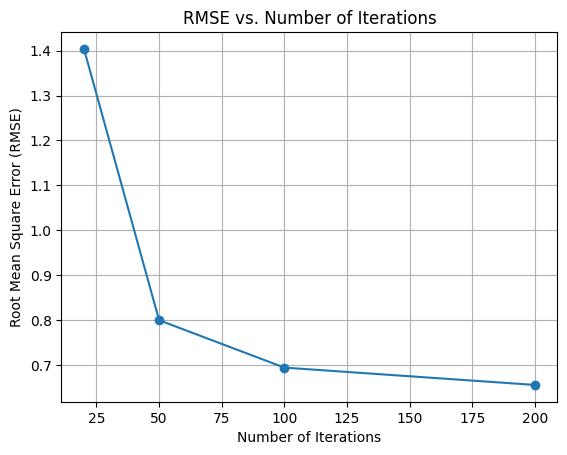

ERRORS:

20 iterations: 1.4039789509925442

50 iterations: 0.7996073631460568

100 iterations: 0.6940361469112143

200 iterations: 0.6554543932216474

Stopping depending on validation set: 0.6706527958221328



In [ ]:
num_iterations = [20, 50, 100, 200]
rmse_values = []
rmse_s = 0
for iterations in num_iterations:
    for seed in range(1, num_runs + 1):
      mlp = MLPRegressor(hidden_layer_sizes=(10, 10), activation='relu', random_state=seed, max_iter=iterations)
      mlp.fit(X_train, y_train)
      y_pred = mlp.predict(X_test)
      rmse_s += np.sqrt(mean_squared_error(y_test, y_pred))

    rmse_values.append(rmse_s/10)
    rmse_s = 0

plt.plot(num_iterations, rmse_values, marker='o')
plt.xlabel('Number of Iterations')
plt.ylabel('Root Mean Square Error (RMSE)')
plt.title('RMSE vs. Number of Iterations')
plt.grid(True)
plt.show()

print(f'''ERRORS:\n
20 iterations: {rmse_values[0]}\n
50 iterations: {rmse_values[1]}\n
100 iterations: {rmse_values[2]}\n
200 iterations: {rmse_values[3]}\n
Stopping depending on validation set: {rmse_mean}\n''')

#4. Commenting the results.
In this case, replacing early stopping worsens the performance of our model. Probably, this is because, in case of early stopping, train data set is 20% less then without early stopping, so in case of exact number of iterations, the model can learn more per iteration. As our model is still in the process of learning and underfitting even up to 200 iterations. It's worth noting that our model doesn't overfit, likely due to its relatively low number of parameters and training on a substantial amount of data compared to the number of model parameters.

#Pen and paper. 2.

In [1]:
import numpy as np

W1 = np.array([[1,1,1,1],[1,1,2,1],[1,1,1,1]])
W2 = np.array([[1,4,1],[1,1,1]])
W3 = np.array([[1,1],[3,1],[1,1]])

b1 = np.array([1,1,1])
b2 = np.array([1,1])
b3 = np.array([1,1,1])



def layer1(x):
  return np.dot(W1,x)+b1

def layer2(x):
  return np.dot(W2,x)+b2

def layer3(x):
  return np.dot(W3,x)+b3

def act_f(x):
    return np.tanh(0.5*x - 2)


def nn(x):
  a1 = layer1(x)
  h1 = act_f(a1)
  a2 = layer2(h1)
  h2 = act_f(a2)
  a3 = layer3(h2)
  h3 = act_f(a3)
  return x,a1,h1,a2,h2,a3,h3

In [2]:
x1 = [1,1,1,1]
x2 = [1,0,0,-1]
z1 = [-1,1,-1]
z2 = [1,-1,-1]

In [3]:
def calc_grad(x, z):

  x, a1, h1, a2, h2, a3, h3 = nn(x)
  print(h3)
  delta3 =(h3 - z) * (1 / (2 * np.cosh(2 - 0.5 * a3)**2))
  grad3 = np.outer(delta3,h2)
  delta2 = W3.T @ delta3 * (1 / (2 * np.cosh(2 - 0.5 * a2)**2))
  grad2 = np.outer(delta2, h1)
  delta1 = W2.T @ delta2 * (1 / (2 * np.cosh(2 - 0.5 * a1)**2))
  grad1 = np.outer(delta1, x)

  return np.array(delta1), np.array(grad1), np.array(delta2), np.array(grad2), np.array(delta3), np.array(grad3)

In [4]:
samples = [x1,x2]
targets = [z1, z2]
for i in range(2):
  if(i==0):
   delta1, grad1, delta2, grad2, delta3, grad3 = calc_grad(samples[i], targets[i])
  else:
    d1, g1, d2, g2, d3, g3 = calc_grad(samples[i], targets[i])
    delta1 += d1
    grad1 += g1
    delta2 += d2
    grad2 += g2
    delta3 += d3
    grad3 += g3

lr = 0.1

b1_new = b1 - lr * delta1
b2_new = b2 - lr * delta2
b3_new = b3 - lr * delta3

W1_new = W1 - lr * grad1
W2_new = W2 - lr * grad2
W3_new = W3 - lr * grad3

print(f'''New params:\n
W1:\n{W1_new}\nW2:\n{W2_new}\nW3:\n{W3_new}\nb1: {b1_new}\nb2: {b2_new}\nb3: {b3_new}\n''')

[-0.91590016 -0.80493961 -0.91590016]
[-0.98652085 -0.9981635  -0.98652085]
New params:

W1:
[[1.0187207  1.01871904 1.01871904 1.01871737]
 [1.03358917 1.03358719 2.03358719 1.03358521]
 [1.0187207  1.01871904 1.01871904 1.01871737]]
W2:
[[1.01730444 4.02851932 1.01730444]
 [1.00467751 1.00771893 1.00467751]]
W3:
[[0.99703633 0.9977484 ]
 [3.01431372 0.98168546]
 [0.99971282 1.00040847]]
b1: [1.0187207  1.03358917 1.0187207 ]
b2: [1.0374494  1.01017306]
b3: [1.00198208 1.03177312 0.99930442]

